This part is focused on analysis of nans, mainly to find any existing patterns of missingness, specifically using cluster analysis on nan indicator matrix.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [ ]:
df = pd.read_csv(r'data\results.txt') 

In [ ]:
schema_df = pd.read_csv(r'data\schema.txt') 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB


Matrix of missing values:

<Axes: >

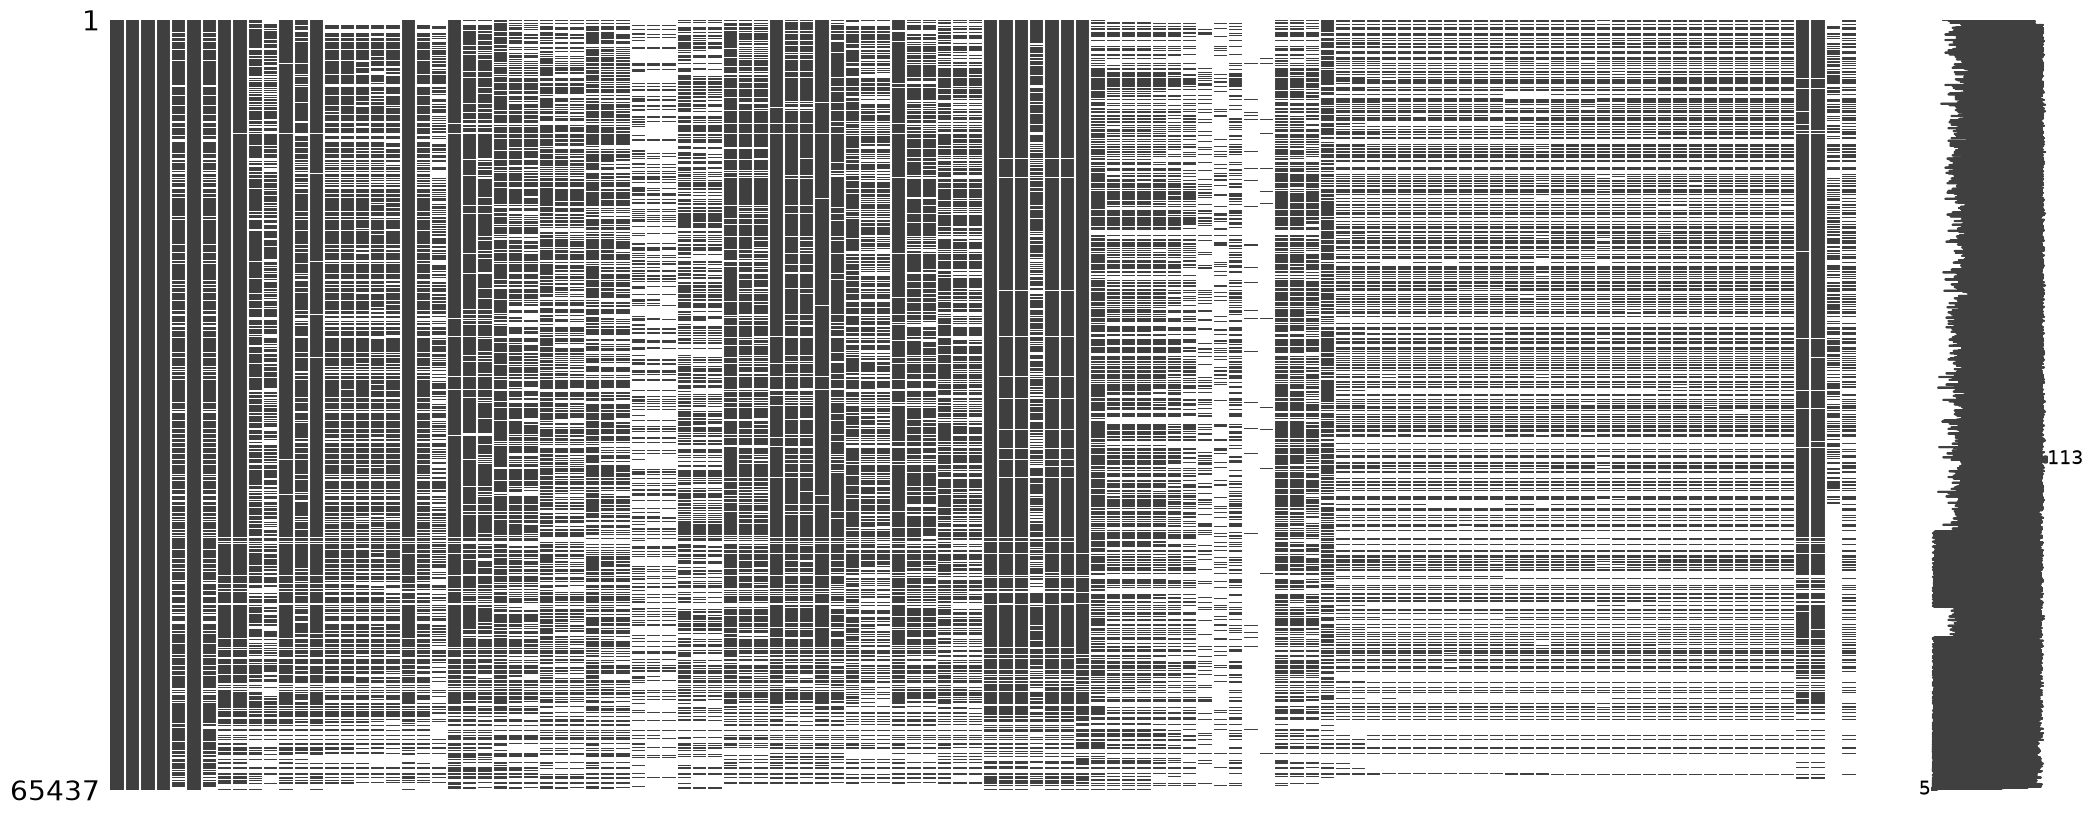

In [5]:
msno.matrix(df)

Percentage of missing values by variable:

In [6]:
nans_perecentage = (df.isnull().sum() / len(df) * 100).reset_index()
nans_perecentage.columns = ['column', 'pct_missing']
nans_perecentage.sort_values('pct_missing', ascending=False).head(20)

,column,pct_missing
75,AINextMuch less integrated,98.245641
74,AINextLess integrated,96.401119
72,AINextNo change,80.900714
71,AINextMuch more integrated,79.464217
36,EmbeddedAdmired,74.428840
35,EmbeddedWantToWorkWith,73.103901
34,EmbeddedHaveWorkedWith,66.052845
112,ConvertedCompYearly,64.186928
70,AIToolNot interested in Using,62.690832
73,AINextMore integrated,62.669438


Several columns are dropped due to reasons as stated in the comments.

In [7]:
cols_to_drop = [
    #more than 60% missing
    'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 
    'AIToolNot interested in Using', 'AINextMuch more integrated', 'AINextNo change', 
    'AINextMore integrated', 'AINextLess integrated', 'AINextMuch less integrated', 
    'ConvertedCompYearly',

    #large portion missing and will make trivial clusters
    'Knowledge_1', 'Knowledge_2', 'Knowledge_3', 'Knowledge_4', 'Knowledge_5',
    'Knowledge_6', 'Knowledge_7', 'Knowledge_8', 'Knowledge_9',

    'Frequency_1', 'Frequency_2', 'Frequency_3',

    'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6',
    'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
    'JobSatPoints_11',

    #no nans by design
    'Check', 'Employment', 'MainBranch', 'ResponseId', 'Age'
]

# errors='ignore' so it won't fail if a column is already missing
df_filtered = df.drop(columns=cols_to_drop, errors='ignore')

For cluster analysis jaccard distance is used, as it fits the character of data the best.

In [8]:
missing_matrix = df_filtered.isnull().astype(int)

co_occurrence = missing_matrix.T.dot(missing_matrix)

cols = missing_matrix.columns
jaccard = pd.DataFrame(index=cols, columns=cols, dtype=float)

for i in cols:
    for j in cols:
        a = missing_matrix[i]
        b = missing_matrix[j]
        intersection = (a & b).sum()
        union = (a | b).sum()
        jaccard.loc[i, j] = intersection / union if union > 0 else 0
    
pairs = []
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append((cols[i], cols[j], jaccard.iloc[i, j]))

pairs_df = pd.DataFrame(pairs, columns=['col1', 'col2', 'jaccard']).sort_values('jaccard', ascending=False)
print(pairs_df.head(5))

                      col1           col2   jaccard
2958         TimeSearching  TimeAnswering  0.993104
2937                ICorPM        WorkExp  0.990052
2813                 AIAcc      AIComplex  0.989061
2993  ProfessionalQuestion       Industry  0.987593
2999              Industry         JobSat  0.986807


Using this dendrograme we aim to determine number of clusters to move forward with.

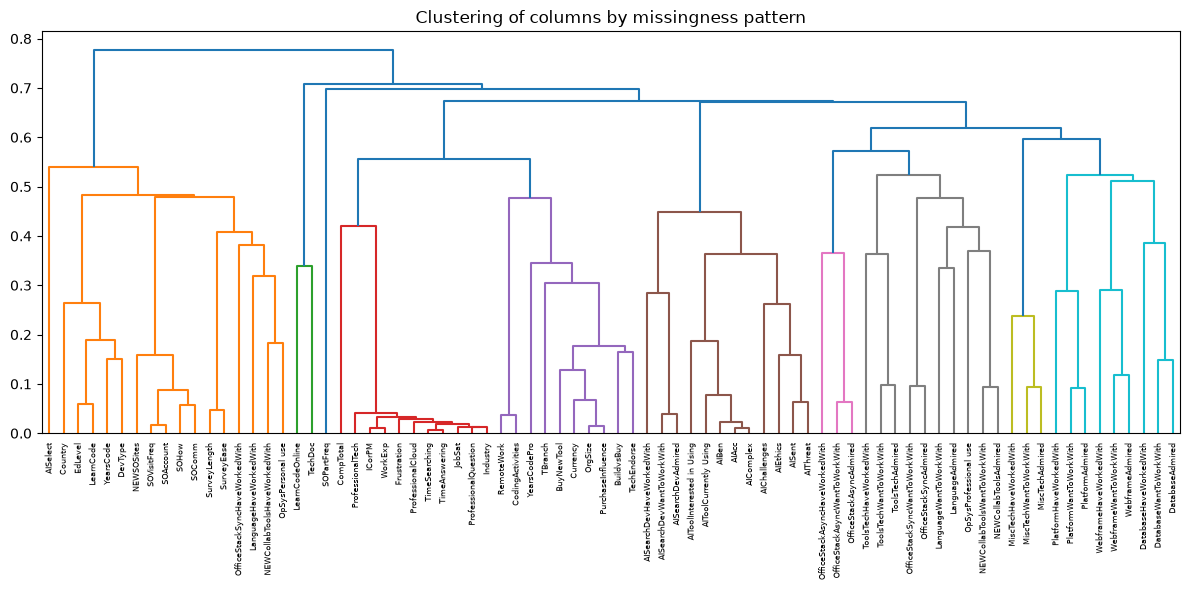

In [9]:
distance_matrix = 1 - jaccard.values.astype(float)
np.fill_diagonal(distance_matrix, 0)

condensed = squareform(distance_matrix, checks=False)

Z = linkage(condensed, method='average')

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=cols.tolist(), leaf_rotation=90)
plt.title("Clustering of columns by missingness pattern")
plt.tight_layout()
plt.show()

Appropriate number of clusters seems to be 11, as at this point they form quite distinct groups.

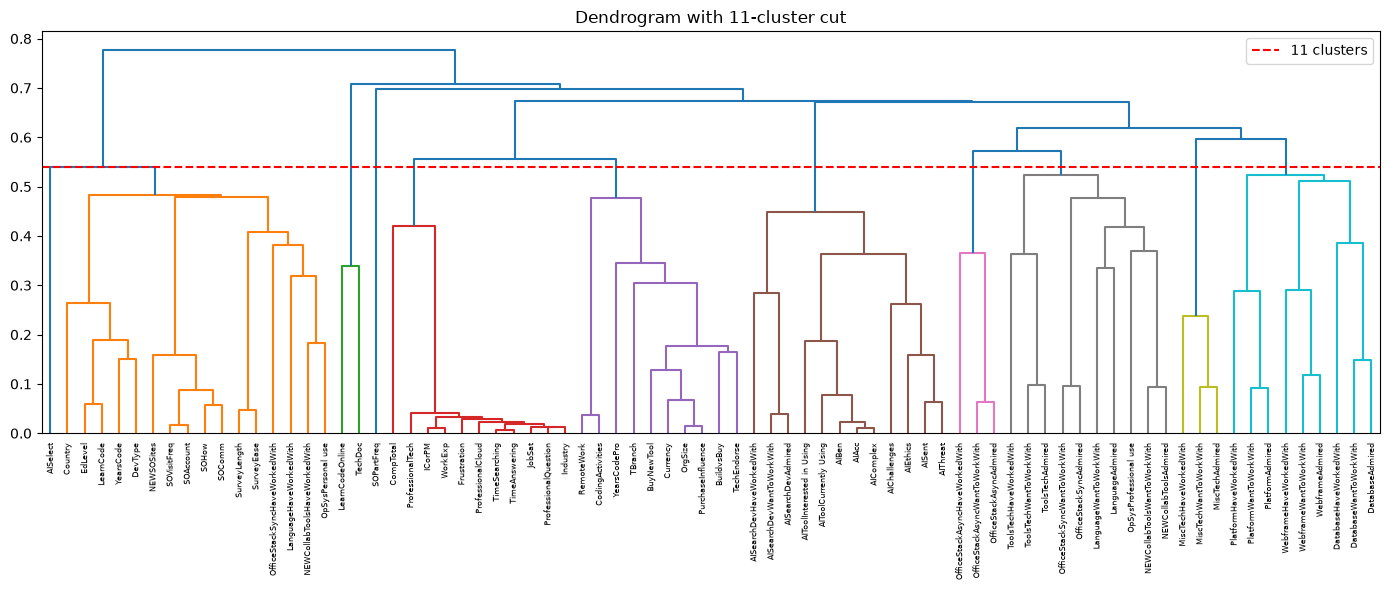

In [10]:
n_clusters = 11
last_merges = Z[-(n_clusters - 1):, 2]
cut_height = last_merges[0] - 1e-6

plt.figure(figsize=(14, 6))
dendrogram(Z, labels=cols.tolist(), leaf_rotation=90, color_threshold=cut_height)
plt.axhline(y=cut_height, color='red', linestyle='--', label=f'{n_clusters} clusters')
plt.legend()
plt.title("Dendrogram with 11-cluster cut")
plt.tight_layout()

plt.savefig('dendrogram.png', dpi=300, bbox_inches='tight')

plt.show()

This provides a look at the components of each cluster to better understand their character.

In [11]:
cluster_labels = fcluster(Z, t=n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({'column': cols, 'cluster': cluster_labels})

for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df.loc[cluster_df['cluster'] == c, 'column'].tolist()
    print(f"\nCluster {c} ({len(members)} columns):")
    for m in members:
        print(f"  - {m}")


Cluster 1 (16 columns):
  - EdLevel
  - LearnCode
  - YearsCode
  - DevType
  - Country
  - LanguageHaveWorkedWith
  - NEWCollabToolsHaveWorkedWith
  - OpSysPersonal use
  - OfficeStackSyncHaveWorkedWith
  - NEWSOSites
  - SOVisitFreq
  - SOAccount
  - SOHow
  - SOComm
  - SurveyLength
  - SurveyEase

Cluster 2 (1 columns):
  - AISelect

Cluster 3 (2 columns):
  - LearnCodeOnline
  - TechDoc

Cluster 4 (11 columns):
  - CompTotal
  - ICorPM
  - WorkExp
  - TimeSearching
  - TimeAnswering
  - Frustration
  - ProfessionalTech
  - ProfessionalCloud
  - ProfessionalQuestion
  - Industry
  - JobSat

Cluster 5 (10 columns):
  - RemoteWork
  - CodingActivities
  - YearsCodePro
  - OrgSize
  - PurchaseInfluence
  - BuyNewTool
  - BuildvsBuy
  - TechEndorse
  - Currency
  - TBranch

Cluster 6 (12 columns):
  - AISearchDevHaveWorkedWith
  - AISearchDevWantToWorkWith
  - AISearchDevAdmired
  - AISent
  - AIBen
  - AIAcc
  - AIComplex
  - AIToolCurrently Using
  - AIToolInterested in Using
  - AI

This part aims to name them appropriately, however it is worth noting that Core Demographics also contains questions aimed at Stack Overflow usage.
Job & Comp while composed of such variables is notably encompasing columns with the highest percentage of missing values.

In [12]:
cluster_names = {
    1: "Core Demographics",
    2: "AI Gate (AISelect)",
    3: "Learning & Docs",
    4: "Job & Comp",
    5: "Work Setup & Purchasing",
    6: "AI Module",
    7: "Async Office Stack",
    8: "Tools & Languages (Want/Admired)",
    9: "Misc Tech",
    10: "Databases/Platforms/Webframes",
    11: "SO Participation"
}

cluster_df['cluster_name'] = cluster_df['cluster'].map(cluster_names)

cluster_df

,column,cluster,cluster_name
0,RemoteWork,5,Work Setup & Purchasing
1,CodingActivities,5,Work Setup & Purchasing
2,EdLevel,1,Core Demographics
3,LearnCode,1,Core Demographics
4,LearnCodeOnline,3,Learning & Docs
...,...,...,...
73,ProfessionalQuestion,4,Job & Comp
74,Industry,4,Job & Comp
75,SurveyLength,1,Core Demographics
76,SurveyEase,1,Core Demographics


Preperation of csv files to be explored via PowerBI.

In [13]:
nans_perecentage = (df_filtered.isnull().sum() / len(df) * 100).reset_index()
nans_perecentage.columns = ['column', 'pct_missing']

In [14]:
df_pairs = jaccard.reset_index().rename(columns={"index": "col1"})

df_pairs = df_pairs.melt(id_vars=["col1"], var_name="col2", value_name="jaccard")

df_pairs = df_pairs[df_pairs["col1"] != df_pairs["col2"]]

In [15]:
nans_perecentage.to_csv('nans_perecentage.csv', index=False)
cluster_df.to_csv('clusters.csv', index=False)
df_pairs.to_csv("jaccard_pairs.csv", index=False)